In [1]:
import os
import cv2
import numpy as np

In [2]:
def load_image(path, img_size=(64, 64)):

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {path}")

    img = cv2.resize(img, img_size)
    img = img.astype(np.float32) / 255.0
    return img.flatten()


In [3]:
def load_dataset(root_dir):
    X = []
    y = []

    for filename in sorted(os.listdir(root_dir)):
        if not filename.lower().endswith(".pgm"):
            continue

        img_path = os.path.join(root_dir, filename)

 
        subject_id = int(filename[7:9]) - 1

        img_vec = load_image(img_path)

        X.append(img_vec)
        y.append(subject_id)

    return np.array(X), np.array(y)


In [ ]:
train_dir = r"Yale_Face_Database\Training"
test_dir  = r"Yale_Face_Database\Testing"

X_train, y_train = load_dataset(train_dir)
X_test, y_test   = load_dataset(test_dir)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (135, 4096) (135,)
Test : (30, 4096) (30,)


In [5]:
######## Part 1

def pca_fit(X):
    
    N, D = X.shape

    # Mean face
    mean_face = np.mean(X, axis=0)

    # Center data
    A = X - mean_face

    # Small covariance matrix
    L = (A @ A.T) / N   # (N, N)

    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(L)

    # Sort descending
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Compute eigenfaces
    eigenfaces = A.T @ eigenvectors  # (D, N)

    # Normalize eigenfaces
    eigenfaces /= np.linalg.norm(eigenfaces, axis=0, keepdims=True)

    return mean_face, eigenfaces, eigenvalues


In [6]:
mean_face, eigenfaces, eigenvalues = pca_fit(X_train)
print(eigenfaces.shape)  # (4096, 135)


(4096, 135)


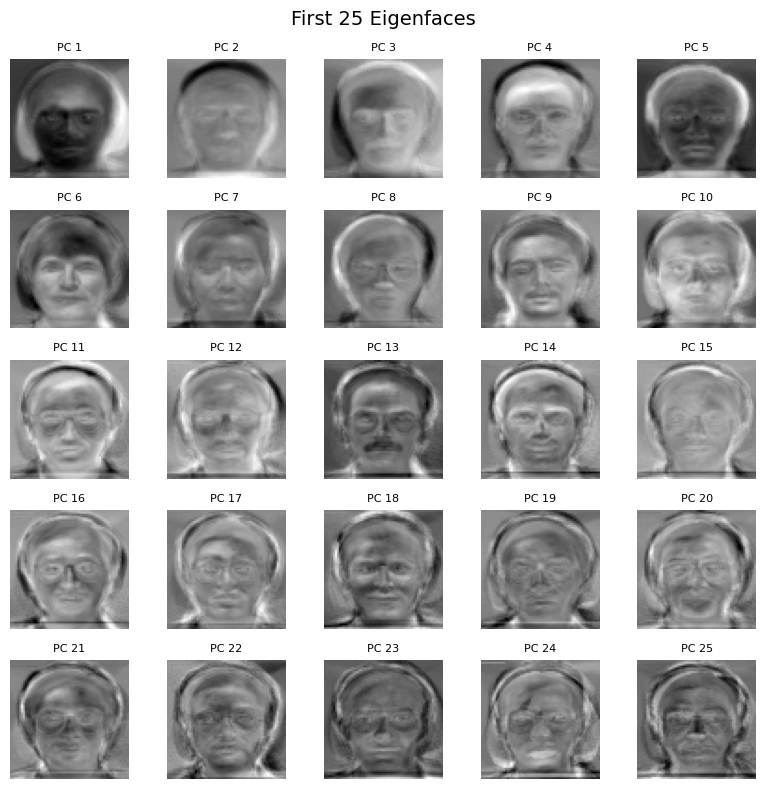

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(eigenfaces[:, i].reshape(64, 64), cmap="gray")
    plt.axis("off")
    plt.title(f"PC {i+1}", fontsize=8)

plt.suptitle("First 25 Eigenfaces", fontsize=14)
plt.tight_layout()
plt.savefig("first_25_eigenfaces.png", dpi=300, bbox_inches="tight")
plt.show()


In [8]:
def pca_project(X, mean_face, eigenfaces, m):
    
   
    return (X - mean_face) @ eigenfaces[:, :m]

def pca_reconstruct(Z, mean_face, eigenfaces, m):
    
    
    return mean_face + Z @ eigenfaces[:, :m].T

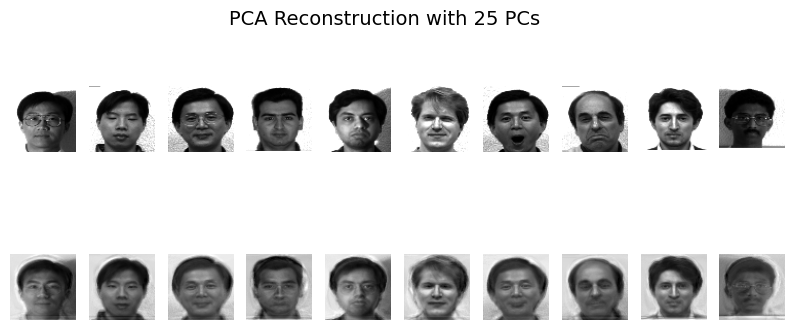

In [9]:
np.random.seed(0)
indices = np.random.choice(len(X_train), 10, replace=False)

m = 25  # number of PCs

Z = pca_project(X_train[indices], mean_face, eigenfaces, m)
X_rec = pca_reconstruct(Z, mean_face, eigenfaces, m)

plt.figure(figsize=(10, 4))
for i in range(10):
    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_train[indices[i]].reshape(64, 64), cmap="gray")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(X_rec[i].reshape(64, 64), cmap="gray")
    plt.axis("off")

plt.suptitle(f"PCA Reconstruction with {m} PCs", fontsize=14)

plt.savefig(
    f"pca_reconstruction_m{m}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [10]:
def knn_predict(Z_train, y_train, Z_test, k=1):
    y_pred = []

    for z in Z_test:
        # Compute distances
        dists = np.linalg.norm(Z_train - z, axis=1)

        # Find k nearest neighbors
        nn_idx = np.argsort(dists)[:k]
        nn_labels = y_train[nn_idx]

        # Majority vote
        values, counts = np.unique(nn_labels, return_counts=True)
        y_pred.append(values[np.argmax(counts)])

    return np.array(y_pred)


In [11]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [12]:
for m in [10, 25, 50, 100]:
    Z_train = pca_project(X_train, mean_face, eigenfaces, m)
    Z_test  = pca_project(X_test,  mean_face, eigenfaces, m)

    for k in [1, 3, 5]:
        y_pred = knn_predict(Z_train, y_train, Z_test, k)
        acc = accuracy(y_test, y_pred)

        print(f"m={m:3d}, k={k}: accuracy = {acc:.3f}")


m= 10, k=1: accuracy = 0.833
m= 10, k=3: accuracy = 0.833
m= 10, k=5: accuracy = 0.833
m= 25, k=1: accuracy = 0.833
m= 25, k=3: accuracy = 0.833
m= 25, k=5: accuracy = 0.867
m= 50, k=1: accuracy = 0.833
m= 50, k=3: accuracy = 0.867
m= 50, k=5: accuracy = 0.900
m=100, k=1: accuracy = 0.867
m=100, k=3: accuracy = 0.833
m=100, k=5: accuracy = 0.867


In [13]:
def compute_scatter(Z, y):
    classes = np.unique(y)
    mean_total = np.mean(Z, axis=0)

    Sw = np.zeros((Z.shape[1], Z.shape[1]))
    Sb = np.zeros_like(Sw)

    for c in classes:
        Zc = Z[y == c]
        mean_c = np.mean(Zc, axis=0)
        diff = Zc - mean_c
        Sw += diff.T @ diff

        n_c = Zc.shape[0]
        mean_diff = (mean_c - mean_total).reshape(-1, 1)
        Sb += n_c * (mean_diff @ mean_diff.T)

    return Sw, Sb

In [14]:
p = 100
Zp_train = pca_project(X_train, mean_face, eigenfaces, p)
Zp_test  = pca_project(X_test,  mean_face, eigenfaces, p)

Sw, Sb = compute_scatter(Zp_train, y_train)
Sw += 1e-6 * np.eye(Sw.shape[0])

eigvals, eigvecs = np.linalg.eig(np.linalg.inv(Sw) @ Sb)
idx = np.argsort(np.real(eigvals))[::-1]
W_lda = np.real(eigvecs[:, idx])



U_pca = eigenfaces[:, :p]
fisherfaces = U_pca @ W_lda[:, :14]
fisherfaces /= np.linalg.norm(fisherfaces, axis=0, keepdims=True)

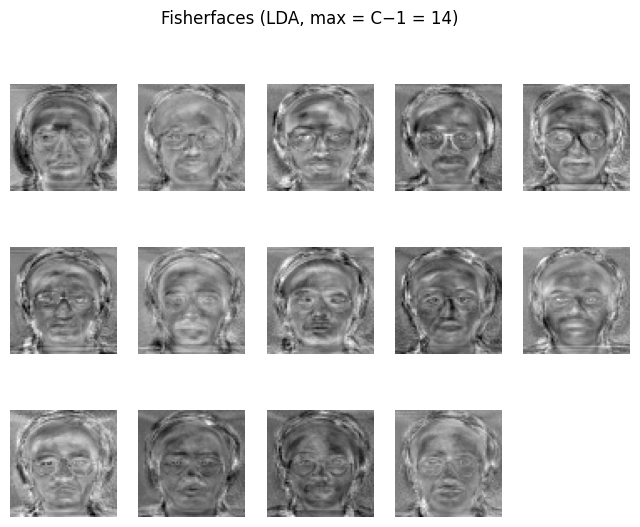

In [15]:
plt.figure(figsize=(8, 6))
for i in range(14):
    plt.subplot(3, 5, i + 1)
    plt.imshow(fisherfaces[:, i].reshape(64, 64), cmap="gray")
    plt.axis("off")

plt.suptitle("Fisherfaces (LDA, max = C−1 = 14)")

plt.savefig(
    "fisherfaces_14.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [16]:
def lda_reconstruct(X, mean, U_pca, W_lda, m):
    Zp = (X - mean) @ U_pca
    Zlda = Zp @ W_lda[:, :m]
    Zp_rec = Zlda @ W_lda[:, :m].T
    return mean + Zp_rec @ U_pca.T


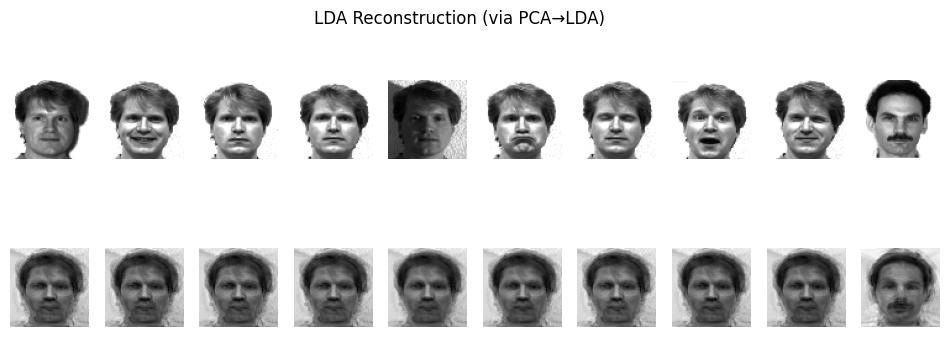

In [17]:
X_rec_lda = lda_reconstruct(
    X_train[idx], mean_face, U_pca, W_lda, 14
)

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_train[idx[i]].reshape(64, 64), cmap="gray")
    plt.axis("off")

    plt.subplot(2, 10, i + 11)
    plt.imshow(X_rec_lda[i].reshape(64, 64), cmap="gray")
    plt.axis("off")

plt.suptitle("LDA Reconstruction (via PCA→LDA)")
plt.savefig(
    "lda_reconstruction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [19]:
Zlda_train = Zp_train @ W_lda[:, :14]
Zlda_test  = Zp_test  @ W_lda[:, :14]

for k in [1, 3, 5]:
    y_pred = knn_predict(Zlda_train, y_train, Zlda_test, k)
    print(f"LDA + kNN (k={k}): accuracy={accuracy(y_test, y_pred):.3f}")


LDA + kNN (k=1): accuracy=0.967
LDA + kNN (k=3): accuracy=0.967
LDA + kNN (k=5): accuracy=0.967


In [20]:
def linear_kernel(X, Y):
    return X @ Y.T

def rbf_kernel(X, Y, gamma):
    X_norm = np.sum(X**2, axis=1).reshape(-1, 1)
    Y_norm = np.sum(Y**2, axis=1).reshape(1, -1)
    return np.exp(-gamma * (X_norm + Y_norm - 2 * X @ Y.T))





In [21]:
def center_kernel(K):
    N = K.shape[0]
    one = np.ones((N, N)) / N
    return K - one @ K - K @ one + one @ K @ one


In [22]:
def kernel_pca_fit(X, kernel_fn, **kernel_params):
    # Compute kernel
    K = kernel_fn(X, X, **kernel_params)

    # Center kernel
    Kc = center_kernel(K)

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(Kc)

    # Sort descending
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # ---- IMPORTANT FIX ----
    # Keep only positive eigenvalues
    pos = eigvals > 1e-8
    eigvals = eigvals[pos]
    eigvecs = eigvecs[:, pos]

    # Normalize eigenvectors
    eigvecs = eigvecs / np.sqrt(eigvals)

    # Store training kernel mean for test centering
    K_mean_row = np.mean(K, axis=0)
    K_mean_all = np.mean(K)

    return {
        "eigvecs": eigvecs,
        "X_train": X,
        "kernel_fn": kernel_fn,
        "kernel_params": kernel_params,
        "K_mean_row": K_mean_row,
        "K_mean_all": K_mean_all
    }


In [23]:
def kernel_pca_project(X_new, model, m):
    eigvecs = model["eigvecs"][:, :m]
    X_train = model["X_train"]
    kernel_fn = model["kernel_fn"]
    params = model["kernel_params"]

    K = kernel_fn(X_new, X_train, **params)

    # Center test kernel using TRAIN statistics
    Kc = (
        K
        - np.mean(K, axis=1, keepdims=True)
        - model["K_mean_row"]
        + model["K_mean_all"]
    )

    return Kc @ eigvecs


In [24]:
gamma = 1e-3
kpca_model = kernel_pca_fit(X_train, rbf_kernel, gamma=gamma)

for m in [10, 20, 30]:
    Ztr = kernel_pca_project(X_train, kpca_model, m)
    Zte = kernel_pca_project(X_test,  kpca_model, m)

    for k in [1, 3, 5]:
        y_pred = knn_predict(Ztr, y_train, Zte, k)
        print(f"kPCA (m={m}, k={k}): acc={accuracy(y_test, y_pred):.3f}")


kPCA (m=10, k=1): acc=0.833
kPCA (m=10, k=3): acc=0.833
kPCA (m=10, k=5): acc=0.833
kPCA (m=20, k=1): acc=0.833
kPCA (m=20, k=3): acc=0.833
kPCA (m=20, k=5): acc=0.867
kPCA (m=30, k=1): acc=0.833
kPCA (m=30, k=3): acc=0.833
kPCA (m=30, k=5): acc=0.867


In [25]:
def lda_fit(Z, y, reg=1e-6):
    classes = np.unique(y)
    mean_total = np.mean(Z, axis=0)

    Sw = np.zeros((Z.shape[1], Z.shape[1]))
    Sb = np.zeros_like(Sw)

    for c in classes:
        Zc = Z[y == c]
        mean_c = np.mean(Zc, axis=0)

        Sw += (Zc - mean_c).T @ (Zc - mean_c)

        diff = (mean_c - mean_total).reshape(-1, 1)
        Sb += Zc.shape[0] * (diff @ diff.T)

    Sw += reg * np.eye(Sw.shape[0])

    eigvals, eigvecs = np.linalg.eig(np.linalg.inv(Sw) @ Sb)
    idx = np.argsort(np.real(eigvals))[::-1]

    return np.real(eigvecs[:, idx])


In [26]:
# ----- Step 1: Kernel PCA -----
gamma = 1e-3
kpca_model = kernel_pca_fit(X_train, rbf_kernel, gamma=gamma)

kpca_dim = 50   # must be > (C-1)
Zkpca_train = kernel_pca_project(X_train, kpca_model, kpca_dim)
Zkpca_test  = kernel_pca_project(X_test,  kpca_model, kpca_dim)

print(Zkpca_train.shape)  # (135, 50)
print(Zkpca_test.shape)   # (30, 50)

# ----- Step 2: LDA in kernel space -----
W_klda = lda_fit(Zkpca_train, y_train)

lda_dim = 14   # C - 1
Zklda_train = Zkpca_train @ W_klda[:, :lda_dim]
Zklda_test  = Zkpca_test  @ W_klda[:, :lda_dim]

print(Zklda_train.shape)  # (135, 14)
print(Zklda_test.shape)   # (30, 14)

# ----- Step 3: kNN classification -----
for k in [1, 3, 5]:
    y_pred = knn_predict(Zklda_train, y_train, Zklda_test, k)
    print(f"Kernel LDA + kNN (k={k}): accuracy = {accuracy(y_test, y_pred):.3f}")


(135, 50)
(30, 50)
(135, 14)
(30, 14)
Kernel LDA + kNN (k=1): accuracy = 0.967
Kernel LDA + kNN (k=3): accuracy = 0.933
Kernel LDA + kNN (k=5): accuracy = 1.000


In [27]:
def plot_2d_scatter(Z, y, title, save_path):
    plt.figure(figsize=(6, 5))
    classes = np.unique(y)
    for c in classes:
        idx = y == c
        plt.scatter(
            Z[idx, 0],
            Z[idx, 1],
            s=20,
            alpha=0.7,
            label=f"Class {c}"
        )
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


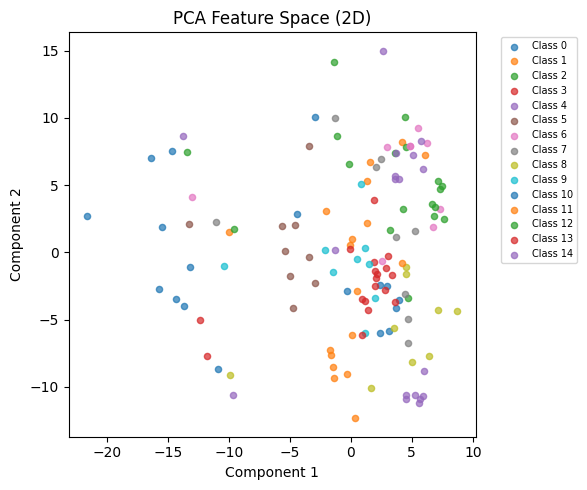

In [28]:
# PCA 2D projection
Zpca_2d = pca_project(X_train, mean_face, eigenfaces, m=2)
plot_2d_scatter(
    Zpca_2d,
    y_train,
    "PCA Feature Space (2D)",
    "pca_scatter.png"
)


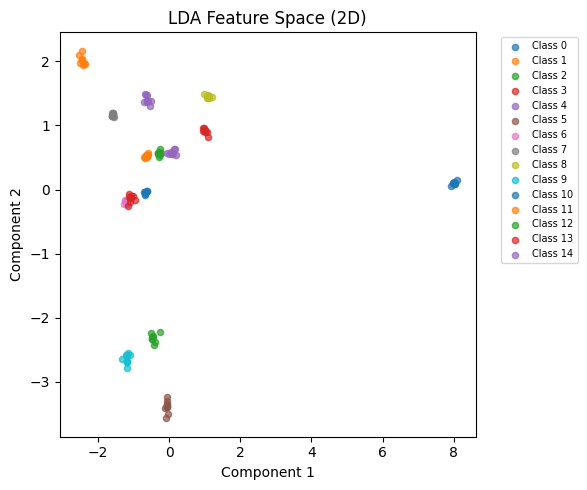

In [30]:
# --- PCA before LDA ---
p = 100
Zp_tr = pca_project(X_train, mean_face, eigenfaces, p)

# --- LDA fit ---
W_lda = lda_fit(Zp_tr, y_train, reg=1e-6)

# --- 2D LDA projection ---
Zlda_2d = Zp_tr @ W_lda[:, :2]

plot_2d_scatter(
    Zlda_2d,
    y_train,
    title="LDA Feature Space (2D)",
    save_path="lda_scatter.png"
)


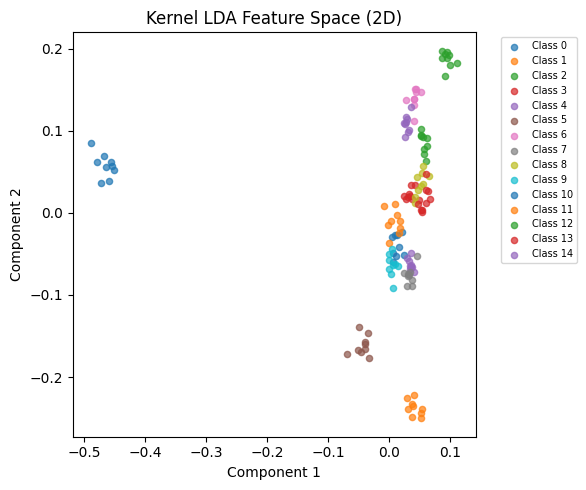

In [32]:
# --- Kernel PCA ---
gamma = 1e-3
kpca_model = kernel_pca_fit(X_train, rbf_kernel, gamma=gamma)
Zkp_tr = kernel_pca_project(X_train, kpca_model, m=50)

# --- Kernel LDA ---
W_klda = lda_fit(Zkp_tr, y_train, reg=1e-6)

# --- Kernel LDA 2D projection ---
Zklda_2d = Zkp_tr @ W_klda[:, :2]

plot_2d_scatter(
    Zklda_2d,
    y_train,
    title="Kernel LDA Feature Space (2D)",
    save_path="klda_scatter.png"
)
